# Sales anaytics using python

## Project Overview
This project analyzes customer purchasing behavior using sales data. The main focus is to understand how revenue is distributed among customers and identify high-value customers.

## Objectives
- Analyze total revenue generated by each customer
- Identify top revenue-contributing customers
- Study customer order frequency
- Segment customers into High, Medium, and Low value groups

## Dataset
The dataset contains sales transaction details such as Order ID, Order Date, Customer Name, and Revenue.

## Key Analysis Performed
- Data cleaning and inspection
- Feature engineering (Month and Year extraction)
- Customer revenue analysis
- Customer order frequency analysis
- Customer segmentation based on revenue

## Data Loading

In this step, the sales dataset is loaded using Pandas for further analysis.

In [1]:
import pandas as pd

df= pd.read_csv("SALES.csv")
df.head()

,Order_ID,Order_Date,Customer_Name,Product,City,Revenue
0,1001,2025-01-01,Arun,Laptop,Chennai,50000
1,1002,2025-01-02,Divya,Mobile,Bangalore,30000
2,1003,2025-01-03,Ravi,Tablet,Hyderabad,25000
3,1004,2025-01-04,Priya,Headphones,Mumbai,6000
4,1005,2025-01-05,Karthik,Keyboard,Delhi,3000


## Data Inspection

The dataset is inspected to understand its structure, data types, and to check for missing values. Basic statistical summary is also generated.

In [2]:
df.info()

print(df.isnull().sum())
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Order_ID       300 non-null    int64 
 1   Order_Date     300 non-null    object
 2   Customer_Name  300 non-null    object
 3   Product        300 non-null    object
 4   City           300 non-null    object
 5   Revenue        300 non-null    int64 
dtypes: int64(2), object(4)
memory usage: 14.2+ KB
Order_ID         0
Order_Date       0
Customer_Name    0
Product          0
City             0
Revenue          0
dtype: int64


,Order_ID,Revenue
count,300.000000,300.000000
mean,1150.500000,32542.000000
std,86.746758,30003.450794
min,1001.000000,2000.000000
25%,1075.750000,7000.000000
50%,1150.500000,24500.000000
75%,1225.250000,52000.000000
max,1300.000000,115000.000000


## Feature Engineering

New features such as Month and Year are extracted from the Order Date to enable time-based analysis.

In [3]:
df["Order_Date"]=pd.to_datetime(df["Order_Date"])

df["Month"]=df["Order_Date"].dt.to_period("M")
df["Year"]=df["Order_Date"].dt.to_period("Y")
df.head()

,Order_ID,Order_Date,Customer_Name,Product,City,Revenue,Month,Year
0,1001,2025-01-01,Arun,Laptop,Chennai,50000,2025-01,2025
1,1002,2025-01-02,Divya,Mobile,Bangalore,30000,2025-01,2025
2,1003,2025-01-03,Ravi,Tablet,Hyderabad,25000,2025-01,2025
3,1004,2025-01-04,Priya,Headphones,Mumbai,6000,2025-01,2025
4,1005,2025-01-05,Karthik,Keyboard,Delhi,3000,2025-01,2025


## Customer Revenue Analysis

Total revenue generated by each customer is calculated to identify top revenue contributors.


In [4]:
Customer_Revenue=df.groupby("Customer_Name")["Revenue"].sum()
Customer_Revenue=Customer_Revenue.sort_values(ascending=False)

Customer_Revenue=Customer_Revenue.reset_index()
Top_Customers=Customer_Revenue.head(5)
Top_Customers




,Customer_Name,Revenue
0,Varun,799000
1,Ritu,729000
2,Arun,700000
3,Lakshmi,680000
4,Priya,628800


### Insight

The top customers contribute a significant portion of total revenue, indicating uneven revenue distribution among customers.

## Top Customers by Revenue - Bar Chart

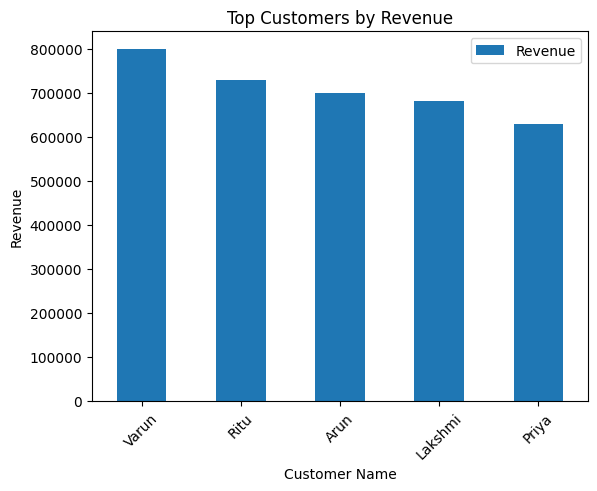

In [8]:
import matplotlib.pyplot as plt

Top_Customers.plot(kind='bar', x='Customer_Name', y='Revenue')
plt.title("Top Customers by Revenue")
plt.xlabel("Customer Name")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

### Insight
The bar chart visually confirms that a few customers contribute significantly higher revenue compared to others.

## Customer Order Frequency

The number of orders placed by each customer is analyzed to understand customer engagement and purchasing behavior.

In [6]:
Customer_Orders=df.groupby("Customer_Name")["Order_ID"].count()

Customer_Orders=Customer_Orders.sort_values(ascending=False)

Customer_Orders=Customer_Orders.reset_index()
Customer_Orders.head()

,Customer_Name,Order_ID
0,Karthik,20
1,Priya,20
2,Arun,10
3,Ajay,10
4,Arvind,10


### Insight

A few customers have high order frequency, while most customers have fewer orders, indicating low overall engagement.

## Customer Segmentation

Customers are categorized into High, Medium, and Low value segments based on their total revenue contribution.

In [7]:
def segment_function(Revenue):
  if Revenue>500000:
    return "High Value"
  elif Revenue>200000:
    return "Medium Value"
  else:
    return "Low Value"

Customer_Revenue["Segment"]=Customer_Revenue["Revenue"].apply(segment_function)
print(Customer_Revenue)

Customer_Revenue.to_excel("Customer_Segment.xlsx",index=False)



   Customer_Name  Revenue       Segment
0          Varun   799000    High Value
1           Ritu   729000    High Value
2           Arun   700000    High Value
3        Lakshmi   680000    High Value
4          Priya   628800    High Value
5         Deepak   593000    High Value
6         Vikram   566000    High Value
7           Neha   565000    High Value
8          Divya   543000    High Value
9         Arvind   461000  Medium Value
10          Asha   457000  Medium Value
11         Nisha   442000  Medium Value
12         Pooja   439500  Medium Value
13          Ravi   413500  Medium Value
14        Anitha   408500  Medium Value
15       Karthik   214700  Medium Value
16          Tina   193600     Low Value
17          Ajay   176900     Low Value
18         Manoj   137300     Low Value
19          John   125000     Low Value
20         Kavya    74700     Low Value
21         Rahul    72000     Low Value
22        Ramesh    69700     Low Value
23         Sneha    66500     Low Value


## Final Insights

1. Revenue Concentration  
A small number of customers contributes a large portion of total revenue.

2. High-Value Customers  
High-value customers generate most of the revenue and are important for business growth.

3. Customer Engagement  
Most customers have low purchase frequency, indicating lower engagement levels.

4. Loyal Customers  
Customers with high order frequency and revenue can be considered loyal customers.

5. Growth Opportunity  
There is potential to increase revenue by improving engagement with medium and low-value customers.